# Bed Shear Stress Spatial and Temporal Patterns

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.dates as mdates
import glob
import os
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon

In [2]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1, polygon_N1, polygon_lon_lat_N1, polygon_N2, polygon_lon_lat_N2, polygon_N3, polygon_lon_lat_N3
from Regions_functions_V2 import polygon_S2, polygon_lon_lat_S2, polygon_C1, polygon_lon_lat_C1, polygon_SP, polygon_lon_lat_SP, polygon_HW1, polygon_lon_lat_HW1
from Regions_functions_V2 import polygon_F1, polygon_lon_lat_F1, polygon_H1, polygon_lon_lat_H1, polygon_J1, polygon_lon_lat_J1, polygon_S3, polygon_lon_lat_S3

In [3]:
begin = pd.to_datetime("2018-01-01")
end = pd.to_datetime("2018-12-31")
t_len = (end - begin).days

In [4]:
import os; import glob; from datetime import timedelta
def date_files(date, path, prefix_type= 'grid_T.nc'):
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path, folder + f'/SalishSea_1h_{date.strftime("%Y%m%d").lower()}_{date.strftime("%Y%m%d").lower()}_{prefix_type}*')
    file_name = glob.glob(prefix) 
    return file_name
#
def get_timestamps(start,length):
    timestamps=[]
    duration = timedelta(days=length)
    for day in range(duration.days):
        timestamps.append([start + timedelta(days=day)])
    return timestamps
#
dates = get_timestamps(begin,t_len)
hourly_dates = pd.date_range(start=begin, end=end, freq='H')[:-1]
#
path_days_h = '/results2/SalishSea/nowcast-green.202111/'
#
files_U = []
files_V = []
files_e3t = []
for i in range(t_len):
    files_U.append(date_files(dates[i][0],path_days_h, prefix_type = 'grid_U.nc'))
    files_V.append(date_files(dates[i][0],path_days_h, prefix_type = 'grid_V.nc'))
    files_e3t.append(date_files(dates[i][0],path_days_h, prefix_type = 'grid_T.nc'))
#
path_bat = '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc'
bat_file = xr.open_dataset(path_bat)
mbathy = bat_file['mbathy'][0]
#     

/tmp/ipykernel_857890/1074250114.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_dates = pd.date_range(start=begin, end=end, freq='H')[:-1]


In [5]:
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

In [6]:
from matplotlib.colors import ListedColormap
colors = [(0, 0, 0, 1),  # Black for land (1)
            (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

In [7]:
shear_2018 = xr.open_dataset('/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/bottom_shear_stress_2018.nc')

In [48]:
from sklearn.decomposition import PCA

# 1. Extract the DataArray
tau = shear_2018['tau']

# 2. Flatten (stack) the spatial dimensions
# This changes shape from (8760, 898, 398) to (8760, 357404)
stacked_data = tau.stack(spatial=('y', 'x'))

# 3. Handle NaNs (Land Mask)
# We assume land points are NaN and remain constant over time. 
# We use the first time step to find valid ocean pixels.
valid_mask = ~np.isnan(stacked_data.isel(time_counter=0).values)

# Extract only the valid ocean pixels across all time steps
# Shape becomes (8760, number_of_ocean_pixels)
ocean_data = stacked_data[:, valid_mask].values 

# 4. Calculate anomalies (Optional but recommended for EOF/PCA)
# Remove the temporal mean from each pixel so PCA focuses on the variance
time_mean = np.mean(ocean_data, axis=0)
ocean_data_anom = ocean_data - time_mean

# 5. Perform the PCA
n_components = 4 # Number of modes to calculate

# For very large matrices, 'randomized' SVD is much faster and uses less memory
pca = PCA(n_components=n_components, svd_solver='randomized') 

print("Fitting PCA... this might take a minute.")
PCs = pca.fit_transform(ocean_data_anom) # Temporal Patterns: shape (8760, 4)
EOFs_1d = pca.components_              # Spatial Patterns (flattened): shape (4, number_of_ocean_pixels)
variance = pca.explained_variance_ratio_

print(f"Variance explained by the first {n_components} modes: {variance * 100}%")

# 6. Reconstruct the Spatial Maps (Unflatten back to 2D)
n_y, n_x = tau.shape[1], tau.shape[2]
EOFs_spatial = np.full((n_components, n_y, n_x), np.nan)

# Map the 1D PCA components back into their correct 2D ocean coordinates
valid_indices = np.where(valid_mask)[0]
for i in range(n_components):
    temp_1d = np.full(n_y * n_x, np.nan)
    temp_1d[valid_indices] = EOFs_1d[i]
    EOFs_spatial[i] = temp_1d.reshape((n_y, n_x))

# 7. Convert results back to Xarray for easy plotting and exporting
EOFs_da = xr.DataArray(
    EOFs_spatial,
    dims=['mode', 'y', 'x'],
    coords={
        'mode': np.arange(1, n_components + 1),
        'nav_lon': tau.nav_lon,
        'nav_lat': tau.nav_lat
    },
    name="Spatial_EOF"
)

PCs_da = xr.DataArray(
    PCs,
    dims=['time_counter', 'mode'],
    coords={
        'time_counter': tau.time_counter,
        'mode': np.arange(1, n_components + 1)
    },
    name="Temporal_PC"
)

Fitting PCA... this might take a minute.
Variance explained by the first 4 modes: [55.688274  11.28877    8.46085    7.0862913]%


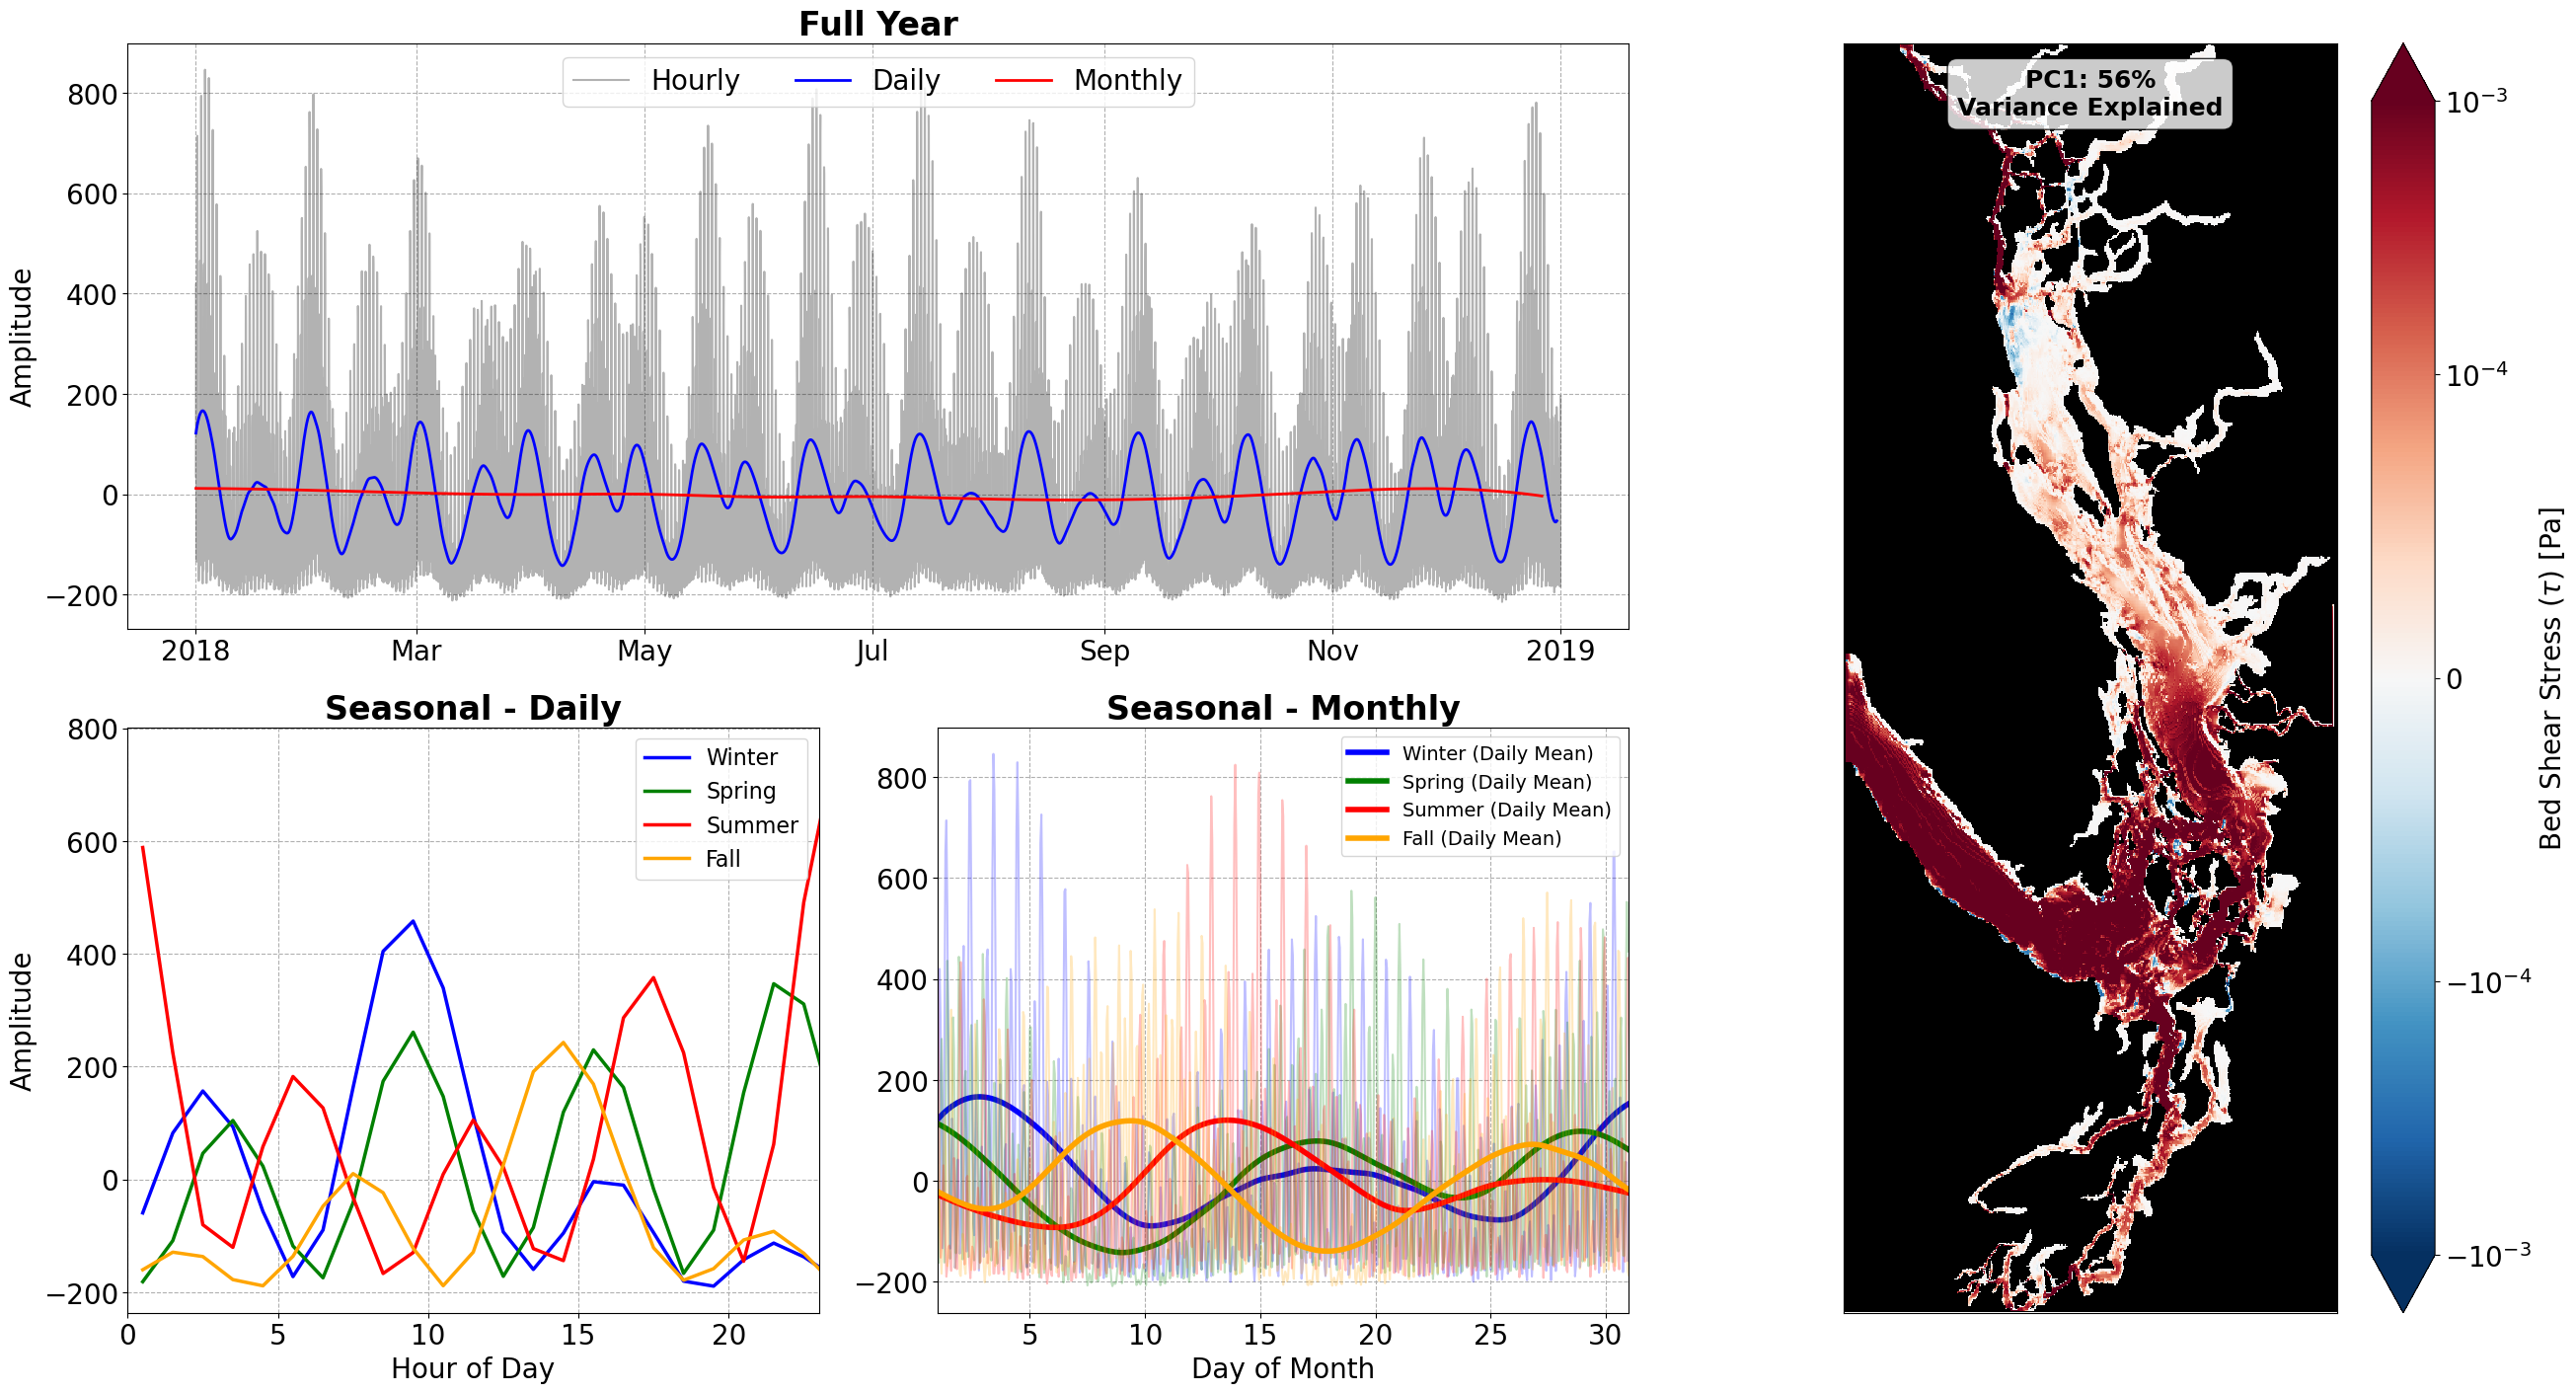

In [50]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

plt.rcParams.update({'font.size': 20})

# 1. Set up the GridSpec layout
fig = plt.figure(figsize=(26, 14), layout='constrained')

gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

# Assign axes to the GridSpec
ax_year = fig.add_subplot(gs[0, 0:2])  # Row 0, spanning Col 0 and 1
ax_day = fig.add_subplot(gs[1, 0])     # Row 1, Col 0
ax_month = fig.add_subplot(gs[1, 1])   # Row 1, Col 1
ax_spat = fig.add_subplot(gs[:, 2])    # Spanning Row 0 and 1, Col 2

# ---------------------------------------------------------
# TEMPORAL PATTERNS (LEFT COLUMNS)
# ---------------------------------------------------------
pc1 = PCs_da.isel(mode=0)

# Pre-calculate the fitted curves (Daily, Weekly, Monthly)
pc1_daily_fit = (
    pc1.resample(time_counter='1D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)
pc1_weekly_fit = (
    pc1.resample(time_counter='7D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)
pc1_monthly_fit = (
    pc1.resample(time_counter='30D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)

# --- Top Panel: Full Year (Daily, Weekly, Monthly Means ONLY) ---
pc1.plot(ax=ax_year, c='k', alpha=0.3, label='Hourly')
pc1_daily_fit.plot(ax=ax_year, c='blue', linewidth=2, label='Daily')
pc1_monthly_fit.plot(ax=ax_year, c='red', linewidth=2, label='Monthly')

ax_year.set_ylabel("Amplitude")
ax_year.set_xlabel("")
ax_year.set_title("Full Year", fontweight='bold')
ax_year.grid(True, linestyle='--')
ax_year.legend(loc='upper center', ncol=3)

# --- Define Seasons for Bottom Plots ---
seasons = {
    'Winter': {'day': '2018-01-15', 'month': '2018-01'},
    'Spring': {'day': '2018-04-15', 'month': '2018-04'},
    'Summer': {'day': '2018-07-15', 'month': '2018-07'},
    'Fall':   {'day': '2018-10-15', 'month': '2018-10'}
}
colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Fall': 'orange'}

# --- Bottom Left Panel: Single Day Seasonal Overlap (Raw Hourly) ---
for season, dates in seasons.items():
    # Extract the specific day
    day_data = pc1.sel(time_counter=dates['day'])
    
    # Normalize x-axis to 0-23 hours so the seasons overlap perfectly
    x_hours = day_data.time_counter.dt.hour + day_data.time_counter.dt.minute / 60.0
    
    ax_day.plot(x_hours, day_data.values, color=colors[season], linewidth = 2.5, label=season)

ax_day.set_ylabel("Amplitude")
ax_day.set_xlabel("Hour of Day")
ax_day.set_xlim(0, 23)
ax_day.set_title("Seasonal - Daily", fontweight='bold')
ax_day.grid(True, linestyle='--')
ax_day.legend(loc='upper right', fontsize=16)

# --- Bottom Right Panel: Single Month Seasonal Overlap (Raw + Daily Mean) ---
for season, dates in seasons.items():
    # Extract the specific month for raw and daily fitted data
    month_data = pc1.sel(time_counter=dates['month'])
    month_daily = pc1_daily_fit.sel(time_counter=dates['month'])
    
    # Normalize x-axis to days 1-31 so the seasons overlap perfectly
    x_days_raw = month_data.time_counter.dt.day + month_data.time_counter.dt.hour / 24.0
    x_days_daily = month_daily.time_counter.dt.day + month_daily.time_counter.dt.hour / 24.0
    
    # Plot raw hourly data as faint lines in the background
    ax_month.plot(x_days_raw, month_data.values, color=colors[season], alpha=0.25)
    
    # Plot daily means as bold lines (add label here to avoid duplicate legend entries)
    ax_month.plot(x_days_daily, month_daily.values, color=colors[season], linewidth = 4, label=f"{season} (Daily Mean)")

ax_month.set_ylabel("") 
ax_month.set_xlabel("Day of Month")
ax_month.set_xlim(1, 31)
ax_month.set_title("Seasonal - Monthly", fontweight='bold')
ax_month.grid(True, linestyle='--')
ax_month.legend(loc='upper right', fontsize=14)

# ---------------------------------------------------------
# SPATIAL PATTERN (RIGHT COLUMN)
# ---------------------------------------------------------
eof1 = EOFs_da.isel(mode=0)

manual_vmin = -1e-3  
manual_vmax =  1e-3  
manual_linthresh = 1e-4

# Plot spatial map
eof1.plot(
    ax=ax_spat, 
    cmap='RdBu_r', 
    norm=SymLogNorm(linthresh=manual_linthresh, vmin=manual_vmin, vmax=manual_vmax, base=10),
    cbar_kwargs={'label': 'Bed Shear Stress '+r'($\tau$) [Pa]'},
    add_labels=False
)

# Plot the model mask on top/background
# (Ensure your 'mask' and 'cmap' variables are defined prior to this step)
ax_spat.pcolormesh(mask['tmask'][0][0], cmap=cmap)
ax_spat.set_aspect(1.14)

# Explicitly clear out spatial titles and labels
ax_spat.set_title("")
ax_spat.set_xlabel("")
ax_spat.set_ylabel("")

var_pct = variance[0] * 100 

# Add the text box to the top right of the spatial plot
ax_spat.text(
    0.5, 0.98,                            
    f'PC1: {var_pct:.0f}%\nVariance Explained',            
    transform=ax_spat.transAxes,           
    fontsize=18,
    fontweight='bold',                     
    ha='center',                            
    va='top',                              
    bbox=dict(                             
        boxstyle='round,pad=0.4', 
        facecolor='white', 
        edgecolor='black', 
        alpha=0.8
    )
)

ax_spat.tick_params(which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.show()

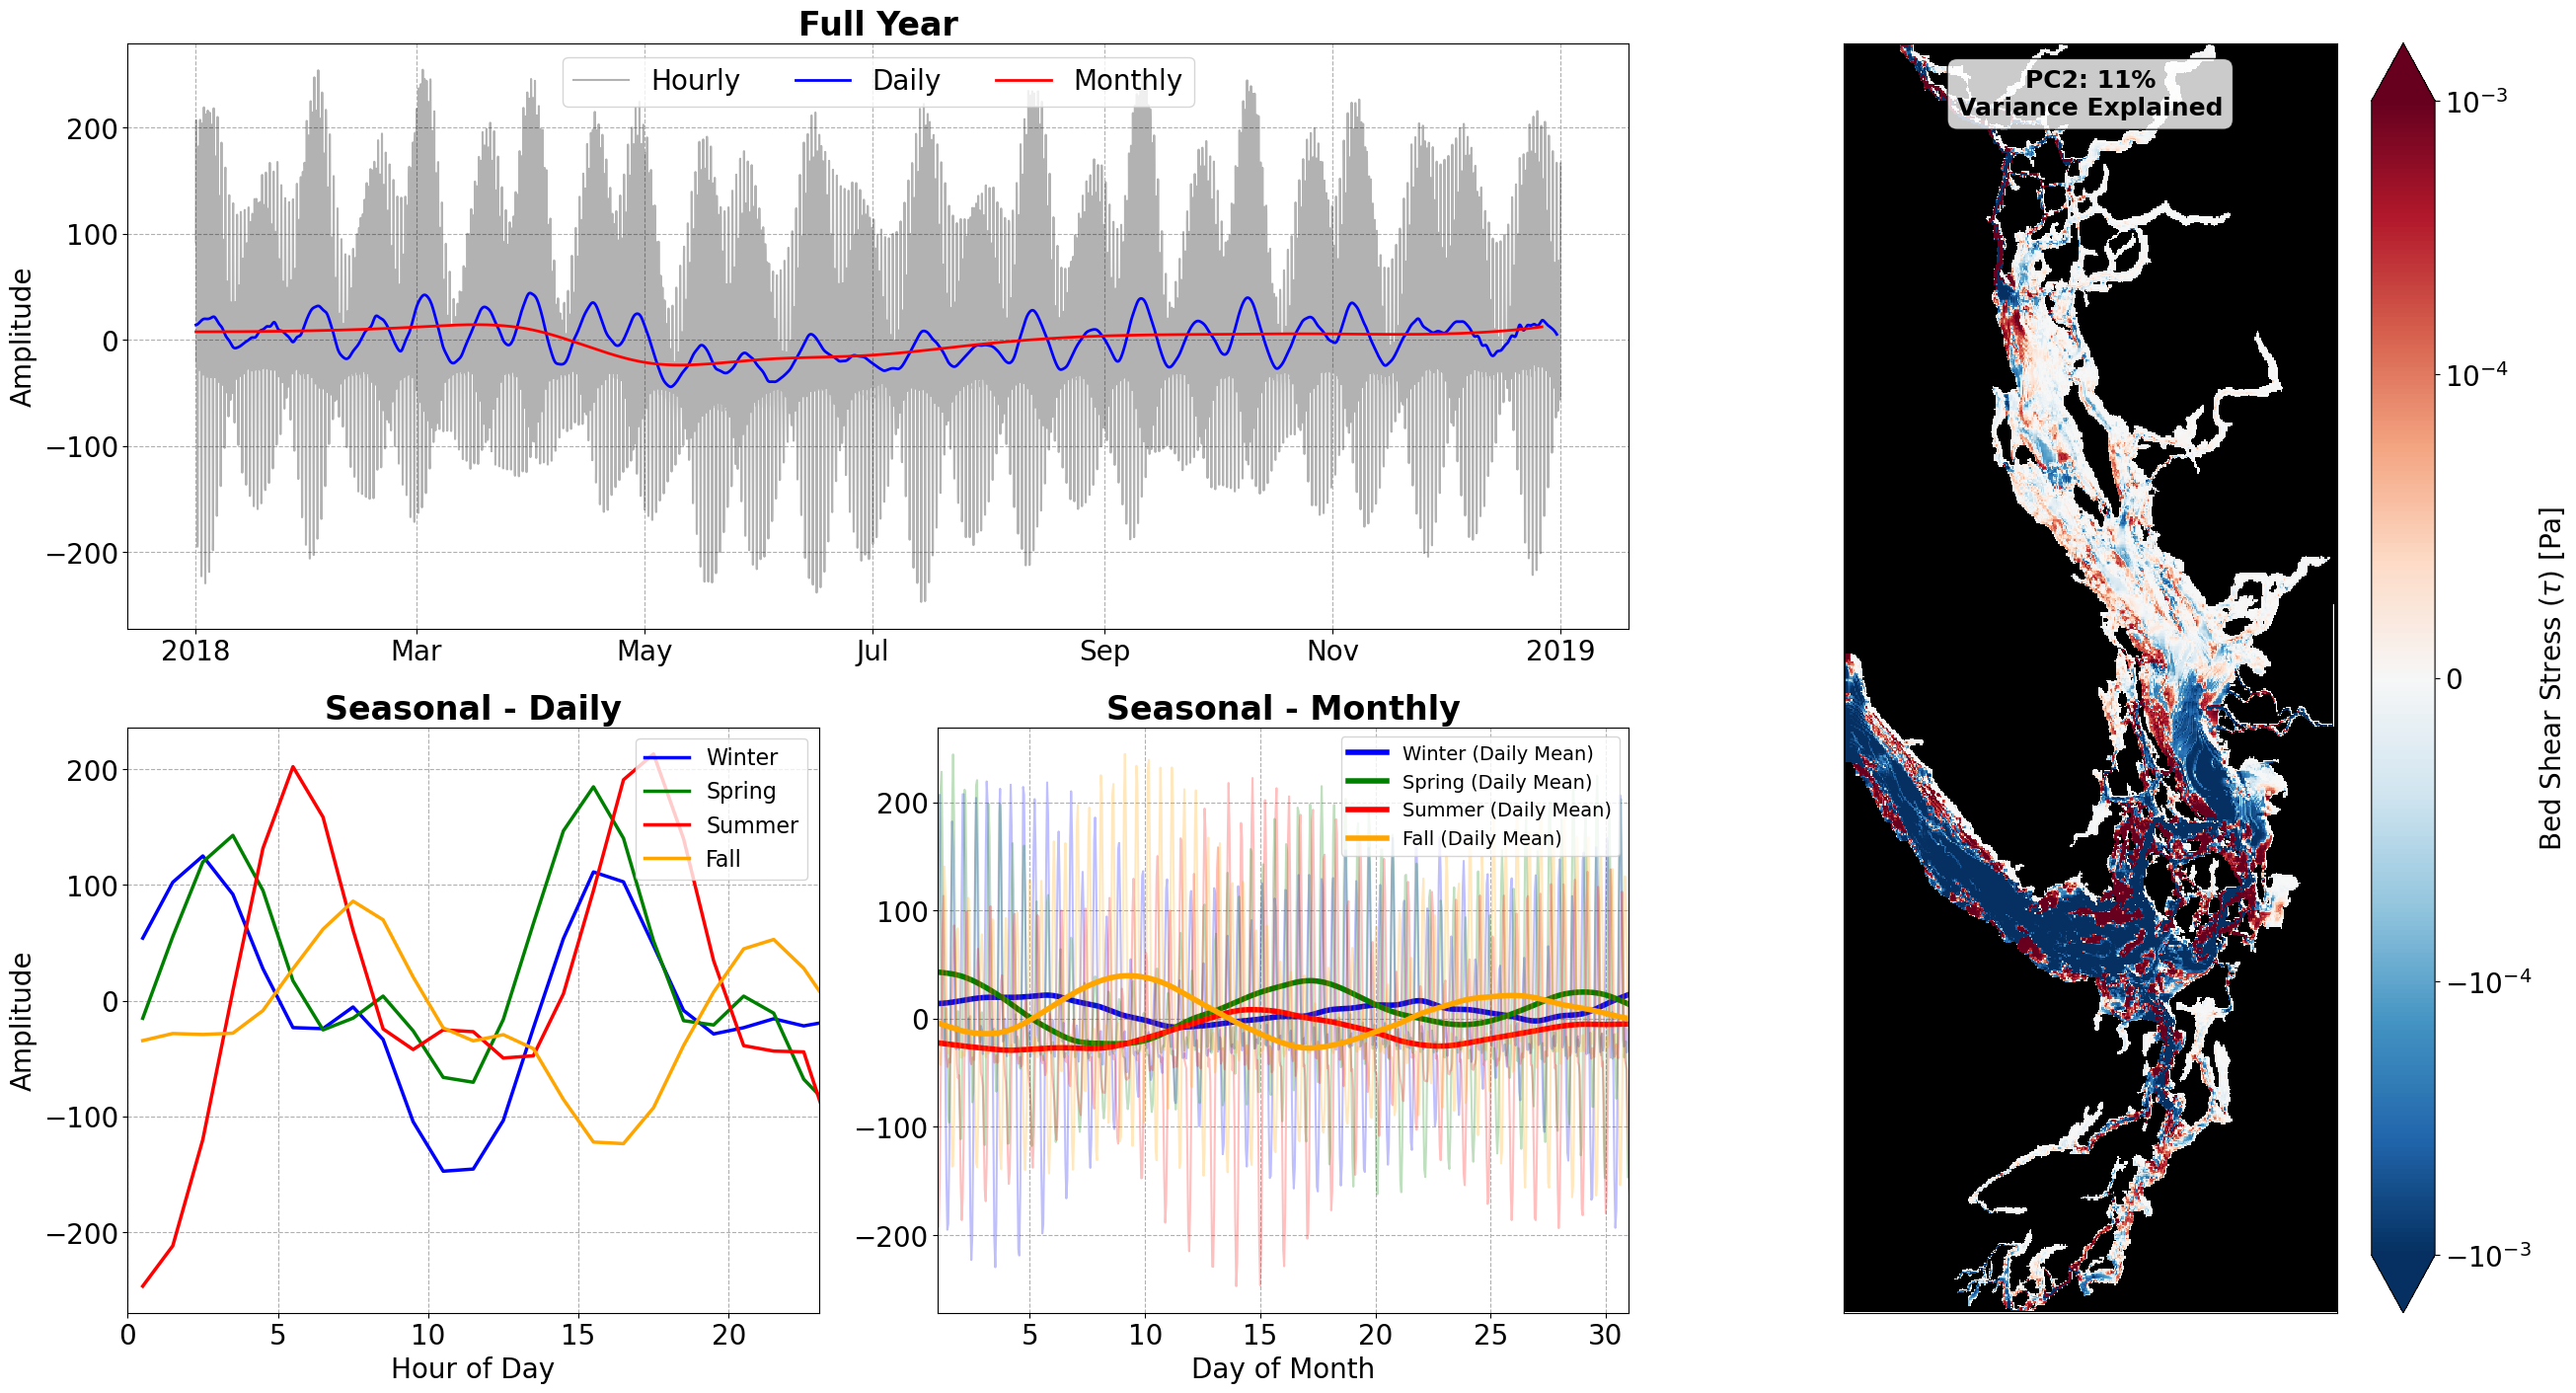

In [51]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

plt.rcParams.update({'font.size': 20})

# 1. Set up the GridSpec layout
fig = plt.figure(figsize=(26, 14), layout='constrained')

gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

# Assign axes to the GridSpec
ax_year = fig.add_subplot(gs[0, 0:2])  # Row 0, spanning Col 0 and 1
ax_day = fig.add_subplot(gs[1, 0])     # Row 1, Col 0
ax_month = fig.add_subplot(gs[1, 1])   # Row 1, Col 1
ax_spat = fig.add_subplot(gs[:, 2])    # Spanning Row 0 and 1, Col 2

# ---------------------------------------------------------
# TEMPORAL PATTERNS (LEFT COLUMNS)
# ---------------------------------------------------------
pc1 = PCs_da.isel(mode=1)

# Pre-calculate the fitted curves (Daily, Weekly, Monthly)
pc1_daily_fit = (
    pc1.resample(time_counter='1D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)
pc1_weekly_fit = (
    pc1.resample(time_counter='7D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)
pc1_monthly_fit = (
    pc1.resample(time_counter='30D').mean()
    .interp(time_counter=pc1.time_counter, method='cubic')
)

# --- Top Panel: Full Year (Daily, Weekly, Monthly Means ONLY) ---
pc1.plot(ax=ax_year, c='k', alpha=0.3, label='Hourly')
pc1_daily_fit.plot(ax=ax_year, c='blue', linewidth=2, label='Daily')
pc1_monthly_fit.plot(ax=ax_year, c='red', linewidth=2, label='Monthly')

ax_year.set_ylabel("Amplitude")
ax_year.set_xlabel("")
ax_year.set_title("Full Year", fontweight='bold')
ax_year.grid(True, linestyle='--')
ax_year.legend(loc='upper center', ncol=3)

# --- Define Seasons for Bottom Plots ---
seasons = {
    'Winter': {'day': '2018-01-15', 'month': '2018-01'},
    'Spring': {'day': '2018-04-15', 'month': '2018-04'},
    'Summer': {'day': '2018-07-15', 'month': '2018-07'},
    'Fall':   {'day': '2018-10-15', 'month': '2018-10'}
}
colors = {'Winter': 'blue', 'Spring': 'green', 'Summer': 'red', 'Fall': 'orange'}

# --- Bottom Left Panel: Single Day Seasonal Overlap (Raw Hourly) ---
for season, dates in seasons.items():
    # Extract the specific day
    day_data = pc1.sel(time_counter=dates['day'])
    
    # Normalize x-axis to 0-23 hours so the seasons overlap perfectly
    x_hours = day_data.time_counter.dt.hour + day_data.time_counter.dt.minute / 60.0
    
    ax_day.plot(x_hours, day_data.values, color=colors[season], linewidth = 2.5, label=season)

ax_day.set_ylabel("Amplitude")
ax_day.set_xlabel("Hour of Day")
ax_day.set_xlim(0, 23)
ax_day.set_title("Seasonal - Daily", fontweight='bold')
ax_day.grid(True, linestyle='--')
ax_day.legend(loc='upper right', fontsize=16)

# --- Bottom Right Panel: Single Month Seasonal Overlap (Raw + Daily Mean) ---
for season, dates in seasons.items():
    # Extract the specific month for raw and daily fitted data
    month_data = pc1.sel(time_counter=dates['month'])
    month_daily = pc1_daily_fit.sel(time_counter=dates['month'])
    
    # Normalize x-axis to days 1-31 so the seasons overlap perfectly
    x_days_raw = month_data.time_counter.dt.day + month_data.time_counter.dt.hour / 24.0
    x_days_daily = month_daily.time_counter.dt.day + month_daily.time_counter.dt.hour / 24.0
    
    # Plot raw hourly data as faint lines in the background
    ax_month.plot(x_days_raw, month_data.values, color=colors[season], alpha=0.25)
    
    # Plot daily means as bold lines (add label here to avoid duplicate legend entries)
    ax_month.plot(x_days_daily, month_daily.values, color=colors[season], linewidth = 4, label=f"{season} (Daily Mean)")

ax_month.set_ylabel("") 
ax_month.set_xlabel("Day of Month")
ax_month.set_xlim(1, 31)
ax_month.set_title("Seasonal - Monthly", fontweight='bold')
ax_month.grid(True, linestyle='--')
ax_month.legend(loc='upper right', fontsize=14)

# ---------------------------------------------------------
# SPATIAL PATTERN (RIGHT COLUMN)
# ---------------------------------------------------------
eof1 = EOFs_da.isel(mode=1)

manual_vmin = -1e-3  
manual_vmax =  1e-3  
manual_linthresh = 1e-4

# Plot spatial map
eof1.plot(
    ax=ax_spat, 
    cmap='RdBu_r', 
    norm=SymLogNorm(linthresh=manual_linthresh, vmin=manual_vmin, vmax=manual_vmax, base=10),
    cbar_kwargs={'label': 'Bed Shear Stress '+r'($\tau$) [Pa]'},
    add_labels=False
)

# Plot the model mask on top/background
# (Ensure your 'mask' and 'cmap' variables are defined prior to this step)
ax_spat.pcolormesh(mask['tmask'][0][0], cmap=cmap)
ax_spat.set_aspect(1.14)

# Explicitly clear out spatial titles and labels
ax_spat.set_title("")
ax_spat.set_xlabel("")
ax_spat.set_ylabel("")

var_pct = variance[1] * 100 

# Add the text box to the top right of the spatial plot
ax_spat.text(
    0.5, 0.98,                            
    f'PC2: {var_pct:.0f}%\nVariance Explained',            
    transform=ax_spat.transAxes,           
    fontsize=18,
    fontweight='bold',                     
    ha='center',                            
    va='top',                              
    bbox=dict(                             
        boxstyle='round,pad=0.4', 
        facecolor='white', 
        edgecolor='black', 
        alpha=0.8
    )
)

ax_spat.tick_params(which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

plt.show()

# Maps of min max values

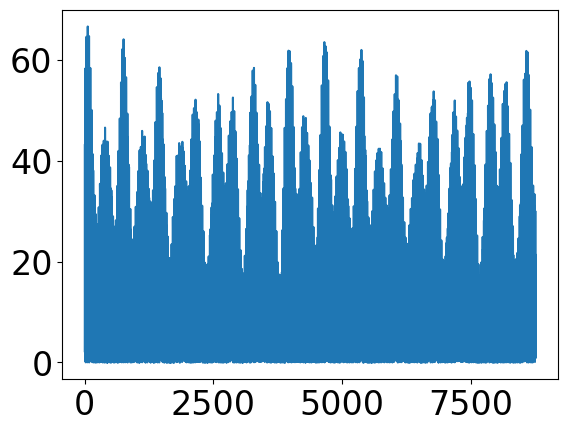

In [104]:
plt.plot(shear_2018['tau'][:,a, b].values)

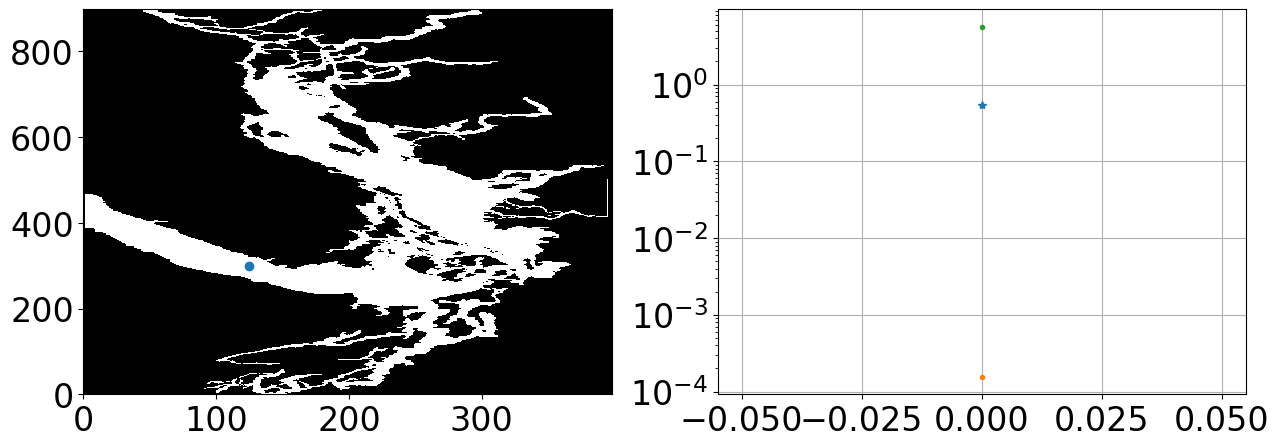

In [124]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].pcolormesh(mask['tmask'][0][0], cmap=cmap)
a, b, = 300, 125
ax[0].scatter(b, a)
ax[1].plot(np.nanmedian(shear_2018['tau'][:,a, b].values), '*')
ax[1].plot(np.nanmin(shear_2018['tau'][:,a, b].values), '.')
ax[1].plot(np.nanmax(shear_2018['tau'][:,a, b].values), '.')
ax[1].set_yscale('log')
ax[1].grid()

In [120]:
np.nanmedian(shear_2018['tau'][:,a, b].values)

3.617346

# Let's see in regions close to Iona

In [55]:
from matplotlib.path import Path
def create_polygon_mask(nav_lon, nav_lat, polygon_coords):
#
    points = np.column_stack((nav_lon.values.flatten(), nav_lat.values.flatten()))
    
    # Create the polygon path
    poly_path = Path(polygon_coords)
    
    # Check which points are inside the polygon
    mask_1d = poly_path.contains_points(points)
    
    # Reshape back to the original 2D grid shape (y, x)
    mask_2d = mask_1d.reshape(nav_lon.shape)
    
    # Convert to an xarray DataArray for seamless masking with your tau dataset
    return xr.DataArray(mask_2d, dims=['y', 'x'])

def get_regional_timeseries(tau_data, mask_da):
#
    regional_data = tau_data.where(mask_da)
    
    # Calculate the spatial mean and std for each time step (collapsing y and x)
    ts_mean = regional_data.mean(dim=['y', 'x'])
    ts_std = regional_data.std(dim=['y', 'x'])
    
    return ts_mean, ts_std

In [56]:
regions = {
    'N1': polygon_lon_lat_N1,
    'N2': polygon_lon_lat_N2,
    'N3': polygon_lon_lat_N3,
    'C1': polygon_lon_lat_C1,
    'S1': polygon_lon_lat_S1,
    'HW1': polygon_lon_lat_HW1,
    'S2': polygon_lon_lat_S2,
    'SP': polygon_lon_lat_SP,
    'F1': polygon_lon_lat_F1,
    'S3': polygon_lon_lat_S3,
    'H1': polygon_lon_lat_H1,
    'J1': polygon_lon_lat_J1
}

# Original tau dataset
tau_data = shear_2018['tau']
lon_grid = tau_data.nav_lon
lat_grid = tau_data.nav_lat

# Dictionary to store the results
regional_results = {}

print("Extracting regional time series...")
for name, coords in regions.items():
    print(f"Processing Region {name}...")
    
    # 1. Create the spatial mask for this specific region
    mask_da = create_polygon_mask(lon_grid, lat_grid, coords)
    
    # 2. Extract the time series
    mean_ts, std_ts = get_regional_timeseries(tau_data, mask_da)
    
    # 3. Store results
    regional_results[name] = {
        'mean': mean_ts,
        'std': std_ts
    }
print("Done!")

Extracting regional time series...
Processing Region N1...
Processing Region N2...
Processing Region N3...
Processing Region C1...
Processing Region S1...
Processing Region HW1...
Processing Region S2...
Processing Region SP...
Processing Region F1...
Processing Region S3...
Processing Region H1...
Processing Region J1...
Done!


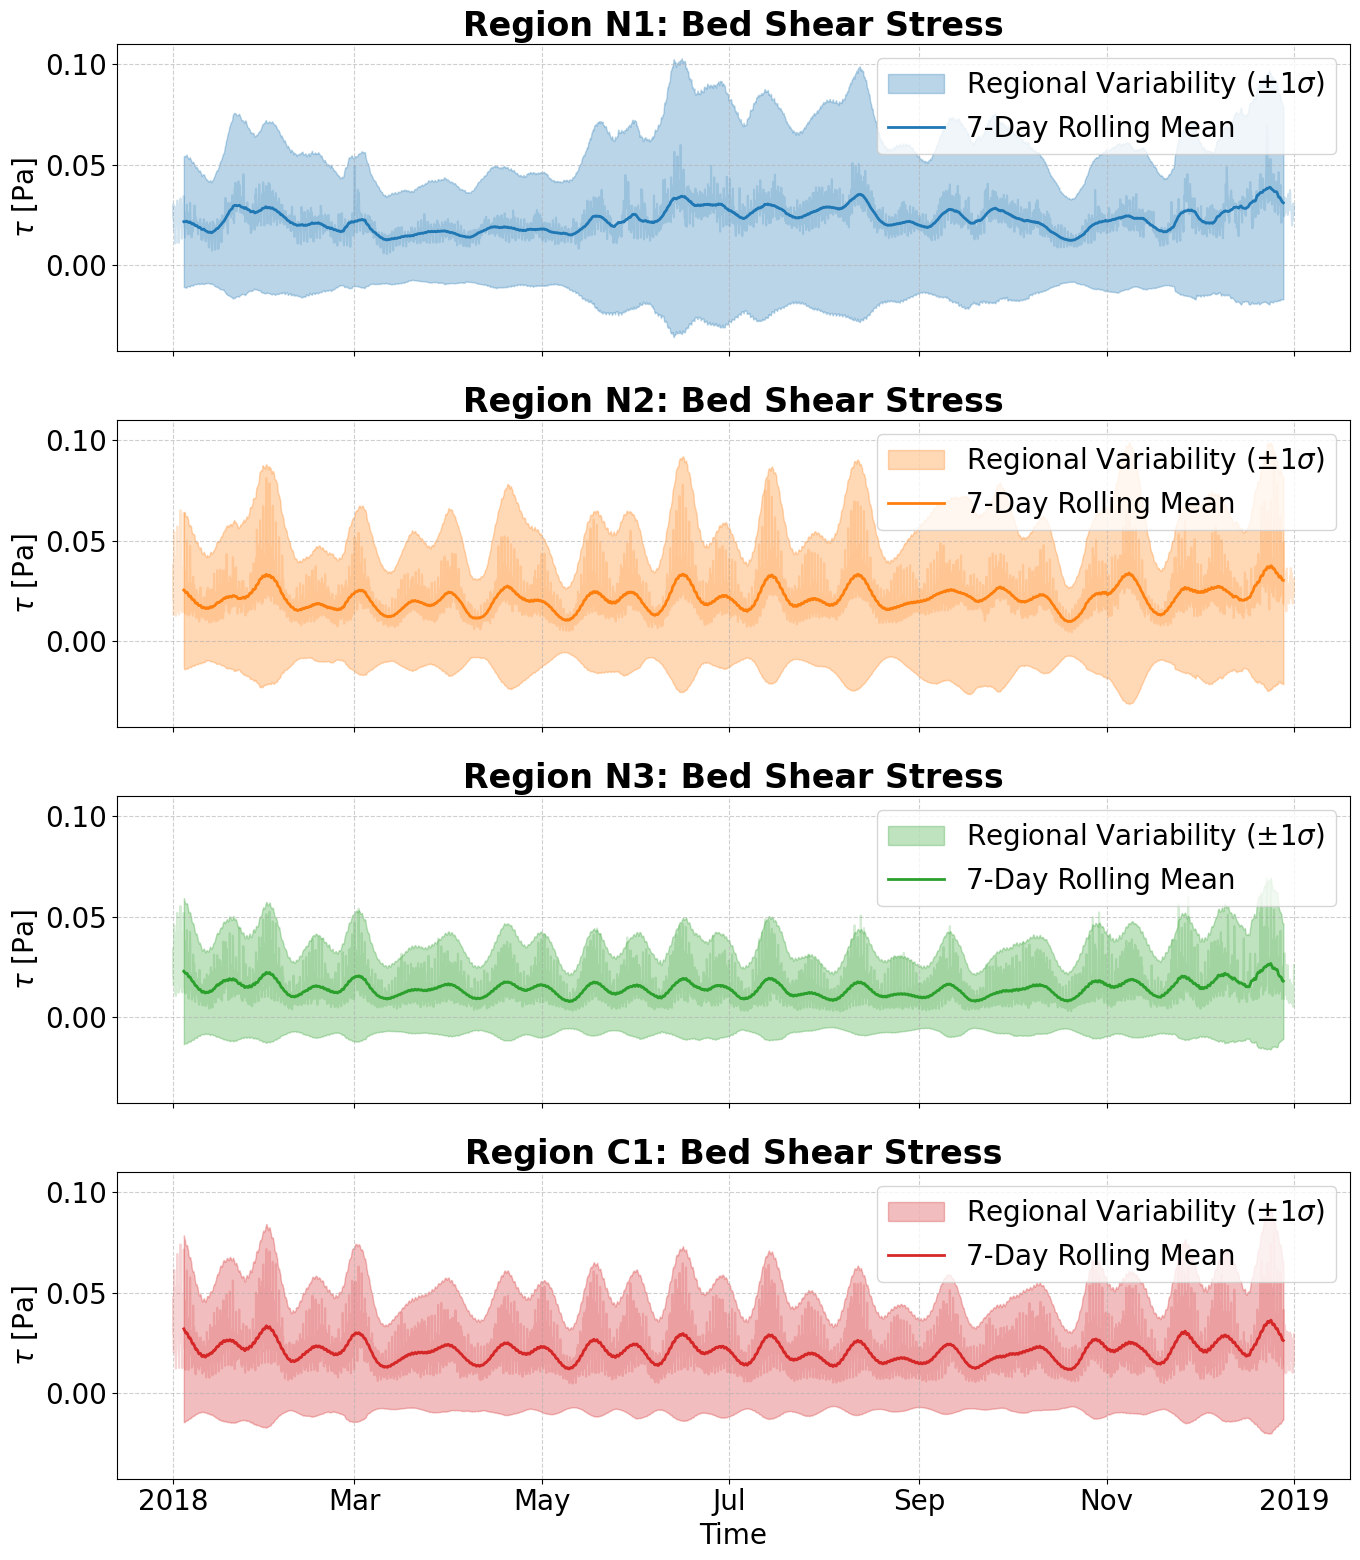

In [57]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True, sharey=True)

# Define the regions to plot and colors
region_names = ['N1', 'N2', 'N3', 'C1', 'S1', 'HW1', 'S2', 'SP', 'F1', 'S3', 'H1', 'J1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (name, ax) in enumerate(zip(region_names, axes)):
    mean_ts = regional_results[name]['mean']
    std_ts = regional_results[name]['std']
    
    # Calculate a 7-day (168 hours) rolling mean to smooth the visual trend
    mean_smooth = mean_ts.rolling(time_counter=168, center=True).mean()
    std_smooth = std_ts.rolling(time_counter=168, center=True).mean()
    
    # Plot the raw hourly mean in the background (faint)
    mean_ts.plot(ax=ax, color=colors[i], alpha=0.2)
    
    # Plot the smoothed envelope (Mean +/- Std)
    ax.fill_between(
        mean_smooth.time_counter, 
        mean_smooth - std_smooth, 
        mean_smooth + std_smooth, 
        color=colors[i], 
        alpha=0.3,
        label=r'Regional Variability ($\pm 1 \sigma$)'
    )
    
    # Plot the smoothed mean on top
    mean_smooth.plot(ax=ax, color=colors[i], linewidth=2, label='7-Day Rolling Mean')
    
    # Formatting
    ax.set_title(f"Region {name}: Bed Shear Stress", fontweight='bold')
    ax.set_ylabel(r"$\tau$ [Pa]")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_xlabel('')
    
    # Ensure standard axis constraints
    #ax.set_ylim(bottom=0) # Tau shouldn't be negative

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

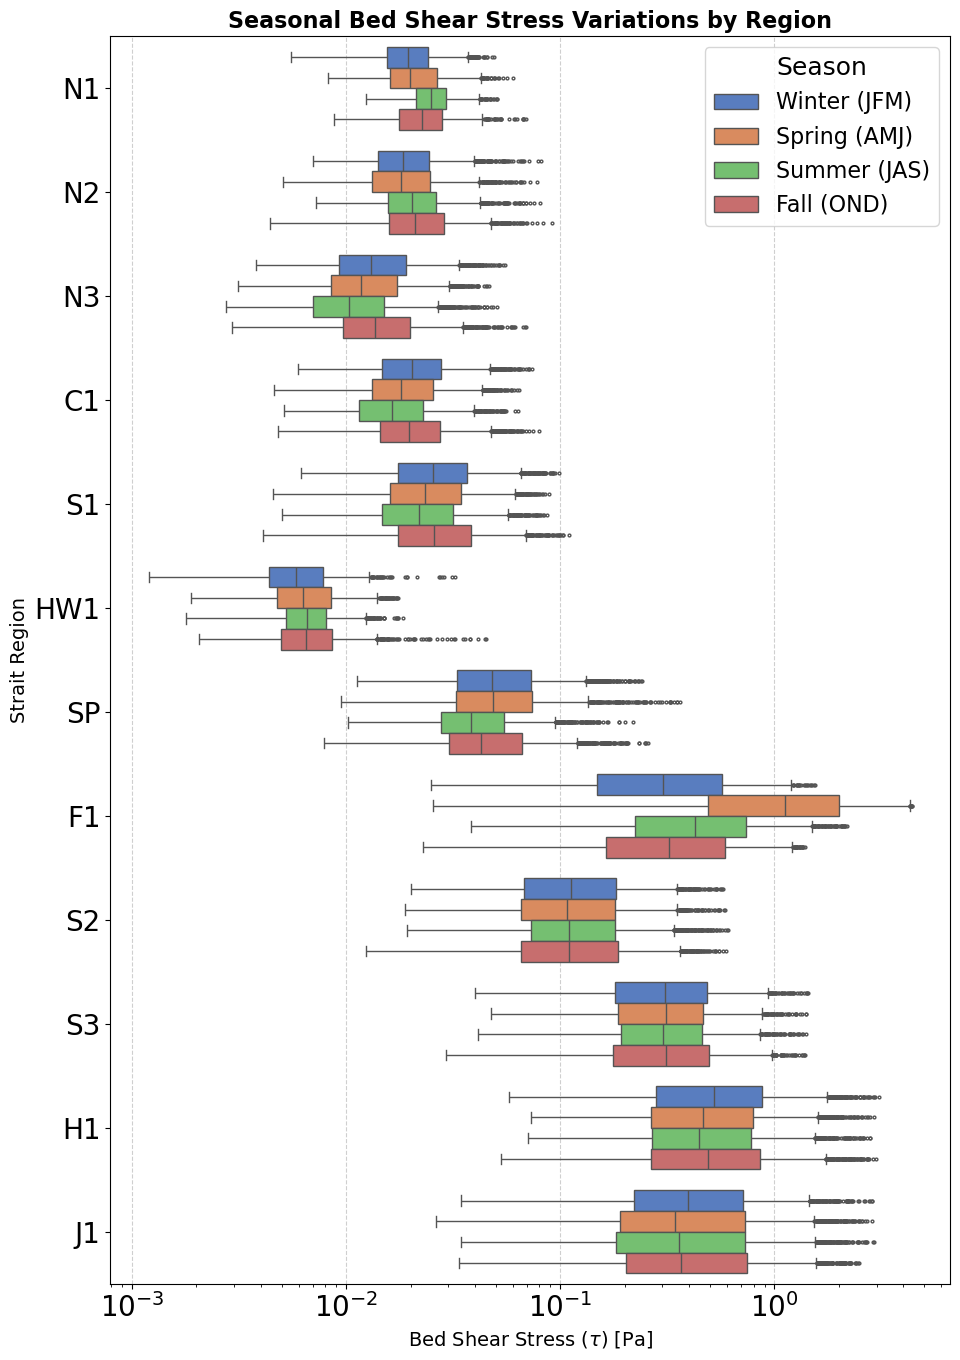

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the full North-to-South ordered list of regions
ordered_regions = ['N1', 'N2', 'N3', 'C1', 'S1', 'HW1', 'SP', 'F1', 'S2', 'S3', 'H1', 'J1']

# 2. Compile the Xarray data into a single Pandas DataFrame
records = []
for region, data in regional_results.items():
    # Extract the raw hourly mean for the region
    da = data['mean']
    
    # Extract the numeric month (1 through 12)
    months = da['time_counter'].dt.month.values
    tau_values = da.values
    
    # Create your custom seasonal mapping
    conditions = [
        months <= 3,                           # Jan, Feb, Mar (1, 2, 3)
        (months >= 4) & (months <= 6),         # Apr, May, Jun (4, 5, 6)
        (months >= 7) & (months <= 9),         # Jul, Aug, Sep (7, 8, 9)
        months >= 10                           # Oct, Nov, Dec (10, 11, 12)
    ]
    choices = ['Winter (JFM)', 'Spring (AMJ)', 'Summer (JAS)', 'Fall (OND)']
    custom_seasons = np.select(conditions, choices)
    
    df_region = pd.DataFrame({
        'Tau': tau_values,
        'Season': custom_seasons,
        'Region': region
    })
    records.append(df_region)

# Combine all regions
df_all = pd.concat(records)

# Reorder seasons chronologically
season_order = ['Winter (JFM)', 'Spring (AMJ)', 'Summer (JAS)', 'Fall (OND)']
df_all['Season'] = pd.Categorical(df_all['Season'], categories=season_order, ordered=True)

# 3. Create the vertical condensed plot
# Use a taller figure to comfortably fit all 12 regions and their 4 seasonal boxes
fig, ax = plt.subplots(figsize=(10, 14)) 

# Horizontal Grouped Boxplot
sns.boxplot(
    data=df_all, 
    x='Tau',               # Assign Shear Stress to the horizontal axis
    y='Region',            # Assign Regions to the vertical axis
    hue='Season', 
    palette='muted', 
    fliersize=2,           # Keep outlier dots small
    order=ordered_regions, # Force the exact top-to-bottom sequence
    ax=ax
)

# 4. Formatting
ax.set_title("Seasonal Bed Shear Stress Variations by Region", fontweight='bold', fontsize=16)
ax.set_xlabel(r"Bed Shear Stress ($\tau$) [Pa]", fontsize=14)
ax.set_ylabel("Strait Region", fontsize=14)

# Change grid lines to vertical so it's easy to read the Tau values across the wide plot
ax.grid(True, axis='x', linestyle='--', alpha=0.6) 

# Because extreme shear stress events create a long tail to the right, 
# the lower right corner is usually completely empty in this orientation.
ax.legend(title='Season', loc='upper right', fontsize=16, title_fontsize=18)

# Optional: If the outliers are extreme enough to compress the boxes too much, 
# uncomment the line below to switch the horizontal axis to a log scale.
ax.set_xscale('log')

plt.tight_layout()
plt.show()

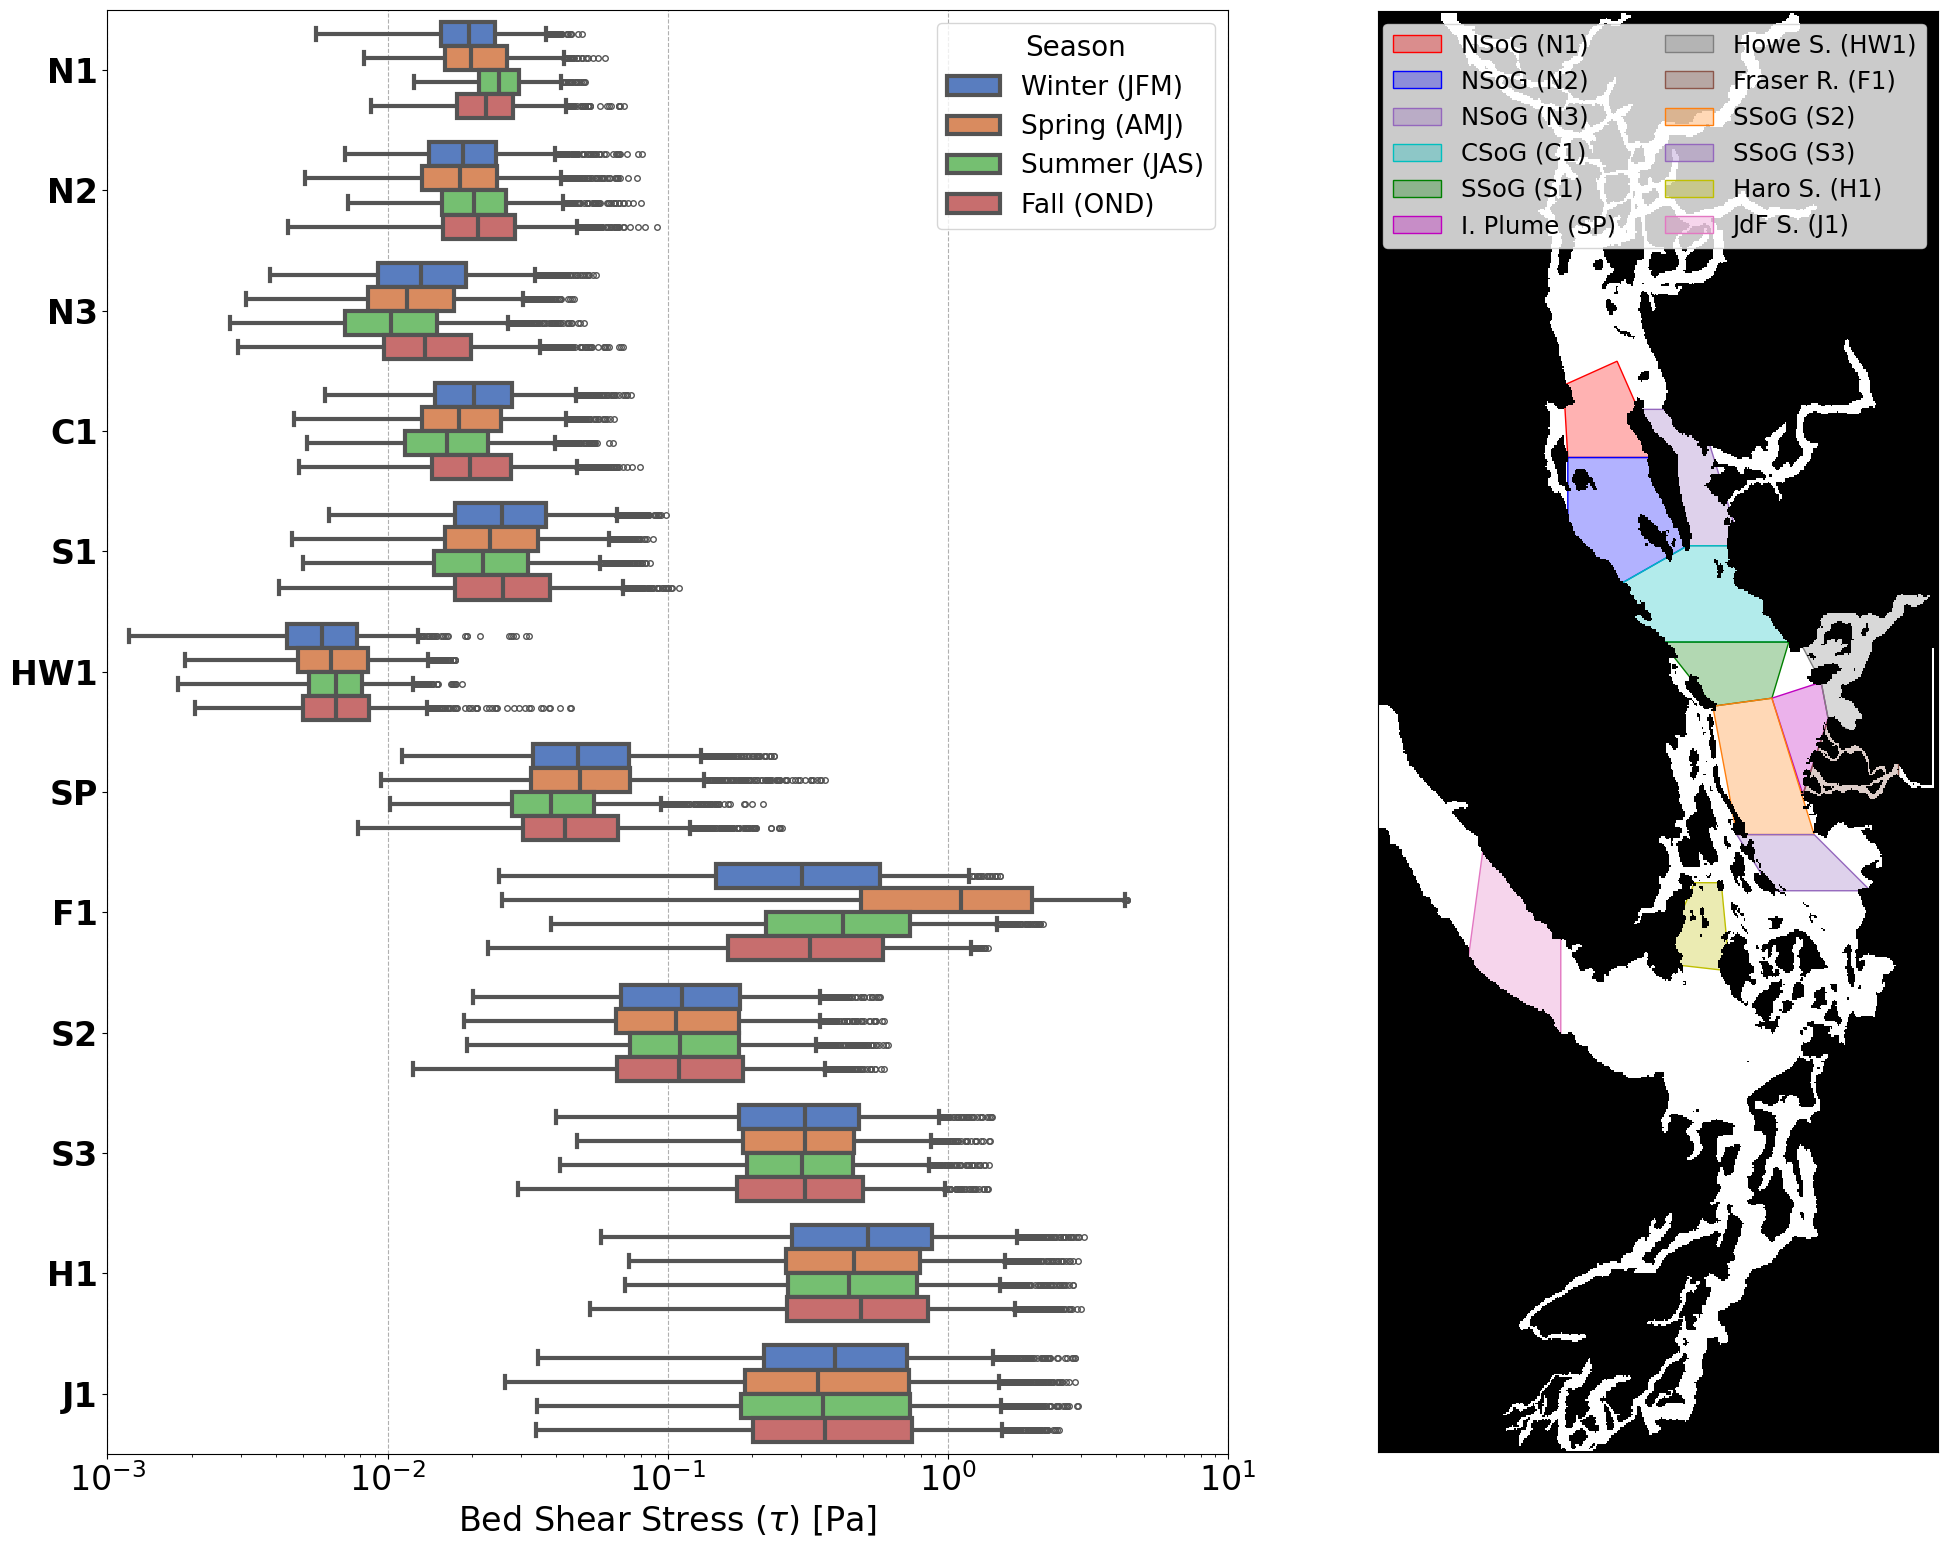

In [65]:
plt.rcParams.update({'font.size': 24})


# 1. Define the full North-to-South ordered list of regions
ordered_regions = ['N1', 'N2', 'N3', 'C1', 'S1', 'HW1', 'SP', 'F1', 'S2', 'S3', 'H1', 'J1']

# 2. Compile the Xarray data into a single Pandas DataFrame
records = []
for region, data in regional_results.items():
    da = data['mean']
    months = da['time_counter'].dt.month.values
    tau_values = da.values
    
    conditions = [
        months <= 3,                           
        (months >= 4) & (months <= 6),         
        (months >= 7) & (months <= 9),         
        months >= 10                           
    ]
    choices = ['Winter (JFM)', 'Spring (AMJ)', 'Summer (JAS)', 'Fall (OND)']
    custom_seasons = np.select(conditions, choices)
    
    df_region = pd.DataFrame({
        'Tau': tau_values,
        'Season': custom_seasons,
        'Region': region
    })
    records.append(df_region)

df_all = pd.concat(records)

season_order = ['Winter (JFM)', 'Spring (AMJ)', 'Summer (JAS)', 'Fall (OND)']
df_all['Season'] = pd.Categorical(df_all['Season'], categories=season_order, ordered=True)

# 3. Create the 1x2 Figure Layout
# Made the figure wider (18, 14) to accommodate both plots side-by-side comfortably
fig, (ax_box, ax_map) = plt.subplots(1, 2, figsize=(20, 16), gridspec_kw={'width_ratios': [2, 1]}) 


sns.boxplot(
    data=df_all, 
    x='Tau',               
    y='Region',            
    hue='Season', 
    palette='muted', 
    fliersize=4,           
    order=ordered_regions, 
    linewidth = 3,
    ax=ax_box
)
ax_box.set_ylabel('')

ax_box.set_xlabel(r"Bed Shear Stress ($\tau$) [Pa]")
ax_box.grid(True, axis='x', linestyle='--') 

# Configure the Log Scale and legend
ax_box.set_xscale('log')
ax_box.legend(title='Season', loc='upper right', fontsize=19, title_fontsize=20)
for label in ax_box.get_yticklabels():
    label.set_fontweight('bold')
ax_box.set_xlim(1e-3, 1e1)

colors_regions = ['r', 'b', 'tab:purple', 'c', 'g', 'm', 'tab:gray', 'tab:brown', 'tab:orange', 'tab:purple', 'y', 'tab:pink']
regions = ['NSoG (N1)', 'NSoG (N2)', 'NSoG (N3)', 'CSoG (C1)', 'SSoG (S1)',
           'I. Plume (SP)', 'Howe S. (HW1)', 'Fraser R. (F1)', 'SSoG (S2)', 'SSoG (S3)', 'Haro S. (H1)', 'JdF S. (J1)']
#
plot_polygon(polygon_N1, ax = ax_map, color=colors_regions[0], label=regions[0],add_points=False)
plot_polygon(polygon_N2, ax = ax_map, color=colors_regions[1], label=regions[1],add_points=False)
plot_polygon(polygon_N3, ax = ax_map, color=colors_regions[2], label=regions[2],add_points=False)
plot_polygon(polygon_C1, ax = ax_map, color=colors_regions[3], label=regions[3],add_points=False)
plot_polygon(polygon_S1, ax = ax_map, color=colors_regions[4], label=regions[4],add_points=False)
plot_polygon(polygon_SP, ax = ax_map, color=colors_regions[5], label=regions[5],add_points=False)
plot_polygon(polygon_HW1, ax = ax_map, color=colors_regions[6], label=regions[6],add_points=False)
plot_polygon(polygon_F1, ax = ax_map, color=colors_regions[7], label=regions[7],add_points=False)
plot_polygon(polygon_S2, ax = ax_map, color=colors_regions[8], label=regions[8],add_points=False)
plot_polygon(polygon_S3, ax = ax_map, color=colors_regions[9], label=regions[9],add_points=False)
plot_polygon(polygon_H1, ax = ax_map, color=colors_regions[10], label=regions[10],add_points=False)
plot_polygon(polygon_J1, ax = ax_map, color=colors_regions[11], label=regions[11],add_points=False)
ax_map.pcolormesh(mask['tmask'][0][0], cmap=cmap, shading='auto')
#
ax_map.set_aspect(1.14)
ax_map.tick_params(which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
ax_map.legend(loc = 'upper right', ncol = 2, fontsize = 17.5)
plt.tight_layout()
plt.show()

In [74]:
1.5*1e-2

0.015

In [ ]:
df_all['']

,Tau,Season,Region
0,0.024023,Winter (JFM),N1
1,0.025026,Winter (JFM),N1
2,0.029970,Winter (JFM),N1
3,0.030343,Winter (JFM),N1
4,0.027080,Winter (JFM),N1
...,...,...,...
8755,0.300554,Fall (OND),J1
8756,0.228558,Fall (OND),J1
8757,0.403546,Fall (OND),J1
8758,0.615367,Fall (OND),J1
